# Exploring the Dataset

This notebook introduces the electricity price and household load data we'll use throughout the workshop.

**Data structure:**
- ~3 years of hourly data stored as flat 1D timeseries
- Arrays are shaped `(26208,)` — one value per hour
- The RL environment will chunk this into episodes of configurable length

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Load the data
prices = np.load('../../03_data/prices.npy')
loads = np.load('../../03_data/loads.npy')

print(f"Prices shape: {prices.shape}")  # (n_hours,)
print(f"Loads shape:  {loads.shape}")   # (n_hours,)
print(f"Total hours:  {len(prices)} ({len(prices) / 24 / 365:.1f} years)")

Prices shape: (26208,)
Loads shape:  (26208,)
Total hours:  26208 (3.0 years)


## Accessing Data

The data is a flat timeseries — each element is one hour:

In [2]:
# Access individual hours
hour_idx = 50
print(f"Hour {hour_idx}:")
print(f"  Price: {prices[hour_idx]:.3f} €/kWh")
print(f"  Load:  {loads[hour_idx]:.3f} kWh")

Hour 50:
  Price: 0.122 €/kWh
  Load:  0.262 kWh


## One Week of Data

Let's visualize the first 168 hours (1 week) of the timeseries.

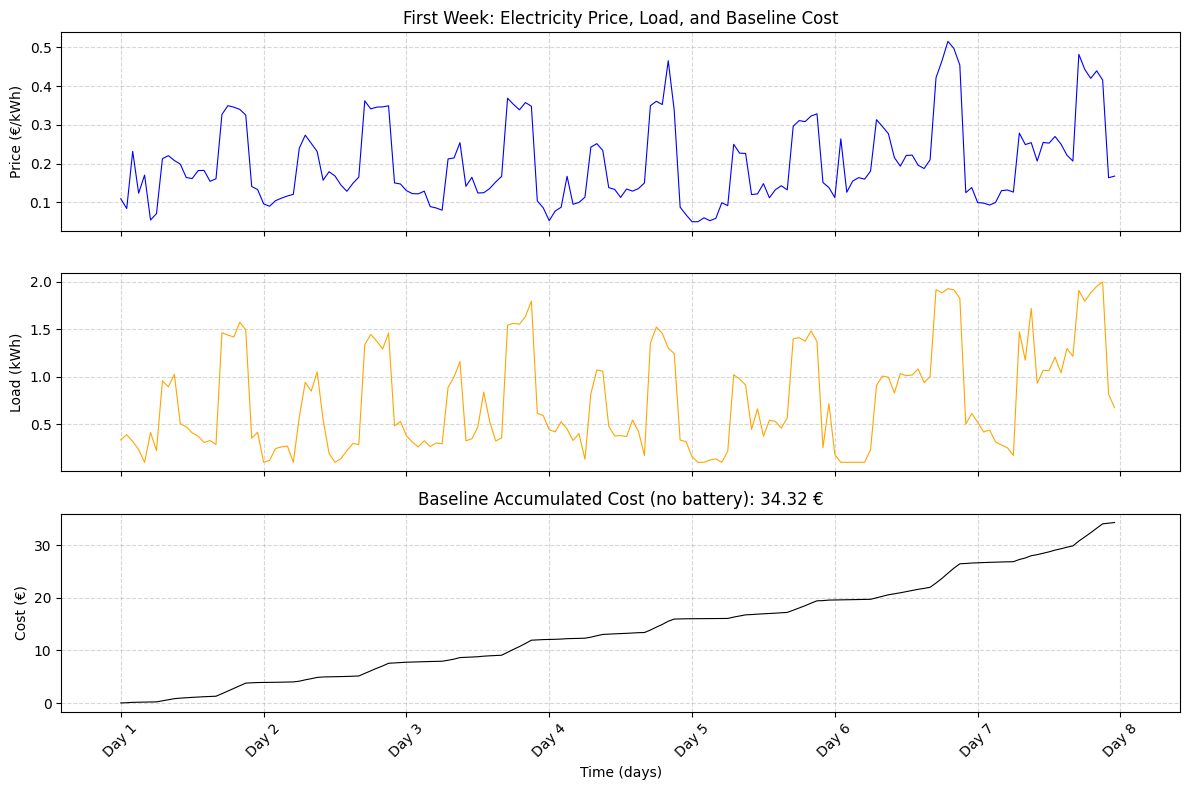

In [3]:
# Plot the first week (168 hours)
episode_length = 168
episode_prices = prices[:episode_length]
episode_loads = loads[:episode_length]
hours = np.arange(episode_length)

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

# Price plot
ax1.plot(hours, episode_prices, 'b-', linewidth=0.8)
ax1.set_ylabel('Price (€/kWh)')
ax1.set_title('First Week: Electricity Price, Load, and Baseline Cost')
ax1.grid(alpha=0.5, linestyle='--')

# Load plot
ax2.plot(hours, episode_loads, color='orange', linewidth=0.8)
ax2.set_ylabel('Load (kWh)')
ax2.grid(alpha=0.5, linestyle='--')

# Accumulated cost for this week
hourly_cost = episode_prices * episode_loads
accumulated_cost = np.cumsum(hourly_cost)
ax3.plot(hours, accumulated_cost, 'black', linewidth=0.8)
ax3.set_ylabel('Cost (€)')
ax3.set_title(f'Baseline Accumulated Cost (no battery): {accumulated_cost[-1]:.2f} €')
ax3.grid(alpha=0.5, linestyle='--')

# Day boundary markers
days = np.arange(0, episode_length + 1, 24)
day_labels = [f'Day {i//24 + 1}' for i in days]
plt.xticks(days, day_labels, rotation=45)
ax3.set_xlabel('Time (days)')
ax3.set_xlim(-10, episode_length + 10)

plt.tight_layout()
plt.show()

## Data Summary

Let's plot a longer stretch of the continuous timeseries (4 weeks) and print summary statistics.

Total time steps in dataset: 26208 hours (3.0 years)

Electricity Prices (€/kWh):
  Min:  0.050
  Max:  0.608
  Mean: 0.205

Household Load (kWh):
  Min:  0.100
  Max:  2.632
  Mean: 0.802


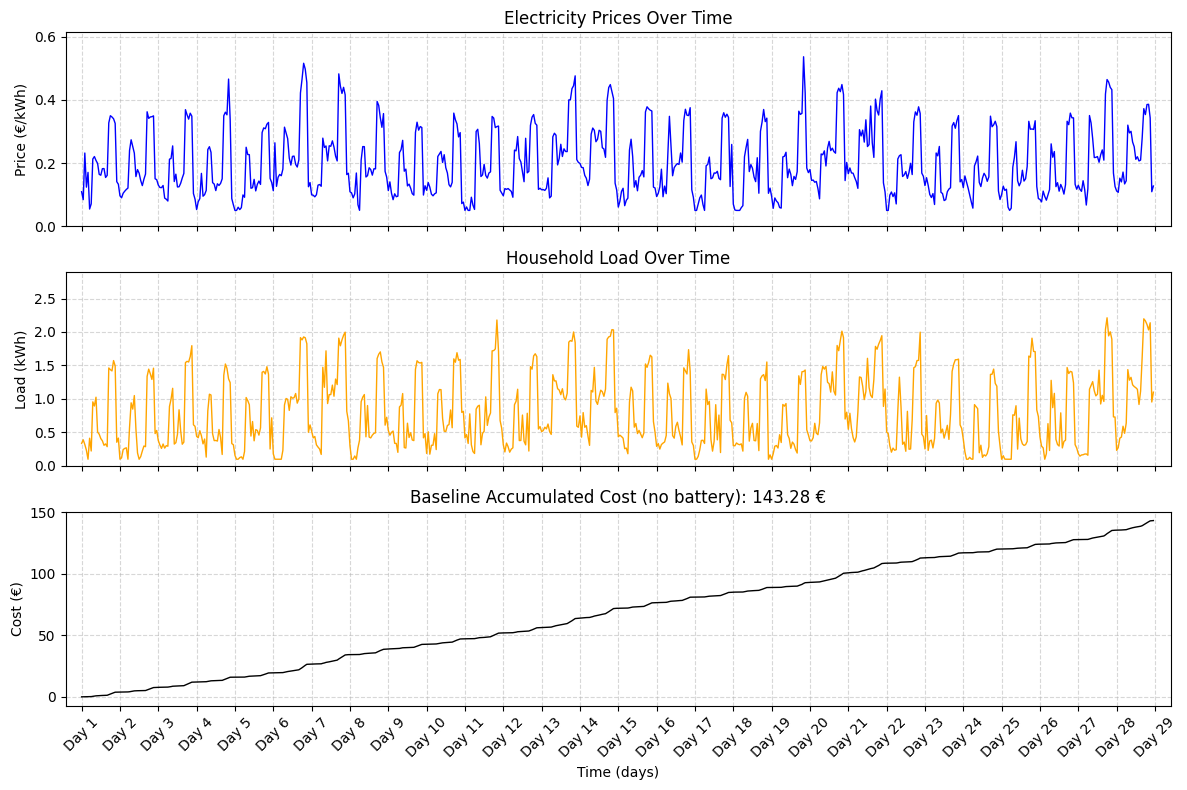

In [4]:
# Print dataset overview
total_hours = len(prices)
print(f"Total time steps in dataset: {total_hours} hours ({total_hours / 24 / 365:.1f} years)\n")

# Plot 4 weeks of the continuous timeseries
hours_to_plot = 4 * 7 * 24
prices_slice = prices[:hours_to_plot]
loads_slice = loads[:hours_to_plot]

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

# Plot electricity prices
ax1.plot(prices_slice, color='blue', linewidth=1)
ax1.set_ylabel('Price (€/kWh)')
ax1.set_title('Electricity Prices Over Time')
ax1.set_ylim(0, prices.max() * 1.01)
ax1.grid(alpha=0.5, linestyle='--')

# Plot household loads
ax2.plot(loads_slice, color='orange', linewidth=1)
ax2.set_ylabel('Load (kWh)')
ax2.set_title('Household Load Over Time')
ax2.set_ylim(0, loads.max() * 1.1)
ax2.grid(alpha=0.5, linestyle='--')

# Plot accumulated baseline cost (no battery)
hourly_cost = prices_slice * loads_slice
accumulated_cost = np.cumsum(hourly_cost)
ax3.plot(accumulated_cost, color='black', linewidth=1)
ax3.set_ylabel('Cost (€)')
ax3.set_title(f'Baseline Accumulated Cost (no battery): {accumulated_cost[-1]:.2f} €')
ax3.grid(alpha=0.5, linestyle='--')

# Set x-ticks to represent days
days = np.arange(0, hours_to_plot + 1, 24)
day_labels = [f'Day {i//24 + 1}' for i in days]
plt.xticks(days, day_labels, rotation=45)
ax3.set_xlabel('Time (days)')
ax3.set_xlim(-10, hours_to_plot + 10)

# Print summary statistics
print("Electricity Prices (€/kWh):")
print(f"  Min:  {prices.min():.3f}")
print(f"  Max:  {prices.max():.3f}")
print(f"  Mean: {prices.mean():.3f}")
print("\nHousehold Load (kWh):")
print(f"  Min:  {loads.min():.3f}")
print(f"  Max:  {loads.max():.3f}")
print(f"  Mean: {loads.mean():.3f}")

plt.tight_layout()
plt.show()

## Key Patterns

Notice the patterns in the data:

- **Prices** are low at night, high in the evening
- **Load** follows daily routines: low at night, peaks in morning and evening
- **Weekends** (Sat/Sun) have different patterns than weekdays

These patterns create opportunities for a "smart" battery to **buy cheap, and use stored energy when prices are high**.